In [ ]:
# ══════════════════════════════════════════════════════════════
# 📦 CELL 1: Install Required Libraries
# ══════════════════════════════════════════════════════════════
!pip install -q transformers peft pandas Pillow torchvision tqdm
!pip install --upgrade torchao
print("✅ Libraries installed successfully!")


✅ Libraries installed successfully!


In [ ]:
# ══════════════════════════════════════════════════════════════
# 📂 CELL 3: Load the Test Data (FIXED FOR REALISTIC RETRIEVAL)
# ══════════════════════════════════════════════════════════════
import pandas as pd
from PIL import Image

CSV_PATH = '..captions/dataset_captionsV2.csv'
IMG_DIR  = '../images'

df = pd.read_csv(CSV_PATH)

# 1. BUILD THE MASSIVE GALLERY (Train + Val + Test)
gallery_images = []
gallery_item_names = []

print("Loading entire database of images (Distractors + Targets)...")
for idx, row in df.iterrows():
    img_path = os.path.join(IMG_DIR, row['found_image'])
    gallery_images.append(Image.open(img_path).convert('RGB'))
    gallery_item_names.append(row['pair_id'])

print(f"✅ Gallery Size: {len(gallery_images)} total images.")

# 2. ISOLATE THE TEST QUERIES
test_df = df[df['split'] == 'test'].reset_index(drop=True)
queries = []
test_item_names = []

for idx, row in test_df.iterrows():
    queries.append(row['positive_caption'])
    test_item_names.append(row['pair_id'])

num_test_items = len(test_df)
print(f"✅ Test Queries: {num_test_items} text descriptions.")

Loading entire database of images (Distractors + Targets)...
✅ Gallery Size: 600 total images.
✅ Test Queries: 90 text descriptions.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 🧠 CELL 4: Load Base Model + LoRA Adapters
# ══════════════════════════════════════════════════════════════
import torch
from transformers import CLIPProcessor, CLIPModel
from peft import PeftModel

base_model_id = "qihoo360/fg-clip-base"
print(f"Downloading Base Model: {base_model_id}...")

processor  = CLIPProcessor.from_pretrained(base_model_id)
base_model = CLIPModel.from_pretrained(base_model_id)

adapter_path = "../lorafinetuned/fgclip-lora-finetunedV2-1200-HNM"  
print(f"Loading Fine-Tuned Adapters from: {adapter_path}...")

lora_model = PeftModel.from_pretrained(base_model, adapter_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
lora_model.to(device)
lora_model.eval()

print("\n✅ Fine-Tuned Model successfully loaded and ready for retrieval!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/601M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: qihoo360/fg-clip-base
Key                                                 | Status     |  | 
----------------------------------------------------+------------+--+-
logit_scale_finegraind                              | UNEXPECTED |  | 
text_model.embeddings.position_embedding_ori.weight | UNEXPECTED |  | 
text_model.embeddings.position_embedding_res.weight | UNEXPECTED |  | 
text_filip_projection.weight                        | UNEXPECTED |  | 
logit_scale_hardneg                                 | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading Fine-Tuned Adapters from: /content/drive/MyDrive/Capstone_Dataset_Final/LORAFINETUNED/fgclip-lora-finetunedV2-1200-HNM...

✅ Fine-Tuned Model successfully loaded and ready for retrieval!


In [ ]:
# ══════════════════════════════════════════════════════════════
# 📋 CELL 5: Configuration & Dataset Summary
# ══════════════════════════════════════════════════════════════
import json
import os as _os

patch_layer = base_model.vision_model.embeddings.patch_embedding
patch_size  = patch_layer.kernel_size[0]
image_size  = 224
num_patches = (image_size // patch_size) ** 2
vit_type    = f"ViT-B/{patch_size}" if patch_size in (16, 32) else f"Unknown"

# ── A. Model Configuration ──────────────────────────────────
print("\n" + "="*60)
print("🧠  MODEL CONFIGURATION")
print("="*60)
print(f"  Base Model:              {base_model_id}")
print(f"  Adapter Path:            {adapter_path}")
print(f"  Adapter Name:            {adapter_path.split('/')[-1]}")
print(f"  ViT Type:                {vit_type}")
print(f"  Patch Size:               {patch_layer.kernel_size[0]}")
print(f"  Stride:                   {patch_layer.stride}")
print(f"  Num Patches:              {num_patches}")
print(f"  Total Patch Embed Dim:   768")
print(f"  CLS Token Embed Dim:     768")
print(f"  Image Size:              {image_size}")
print(f"  Device:                  {device}")

# ── B. Training Configuration ───────────────────────────────
adapter_config_path = os.path.join(adapter_path, "adapter_config.json")
trainer_state_path  = os.path.join(adapter_path, "trainer_state.json")

# LoRA params — read from the actual saved adapter_config.json (always available)
lora_rank     = "N/A"
lora_alpha    = "N/A"
lora_dropout  = "N/A"
lora_targets  = "N/A"

# Training hyperparameters — NOT stored in adapter files by default.
# Fill these in manually (or add a custom config file to your adapter folder).
# They are left as N/A because hardcoding fallbacks would produce misleading output.
lr            = "N/A"   # e.g. "5e-5"
weight_decay  = "N/A"
warmup_ratio  = "N/A"
scheduler_type = "N/A"
loss_temp      = "N/A"
augmentations  = "N/A"
batch_size     = "N/A"
epochs_trained = "N/A"

try:
    with open(adapter_config_path, "r") as f:
        cfg = json.load(f)
    lora_rank    = cfg.get("r",         "N/A")
    lora_alpha   = cfg.get("lora_alpha","N/A")
    lora_dropout = cfg.get("lora_dropout","N/A")
    target_mods  = cfg.get("target_modules", [])
    lora_targets  = ", ".join(target_mods) if isinstance(target_mods, list) else str(target_mods)
except (FileNotFoundError, json.JSONDecodeError, IOError):
    pass

print("\n" + "="*60)
print("⚙️  TRAINING CONFIGURATION")
print("="*60)
print(f"  LoRA Rank:                {lora_rank}")
print(f"  LoRA Alpha:               {lora_alpha}")
print(f"  LoRA Dropout:             {lora_dropout}")
print(f"  LoRA Target Modules:      {lora_targets}")
print(f"  Learning Rate:           {lr}")
print(f"  Weight Decay:            {weight_decay}")
print(f"  Scheduler:               {scheduler_type}")
print(f"  Warmup Ratio:            {warmup_ratio}")
print(f"  Loss Temperature:        {loss_temp}")
print(f"  Augmentations:          {augmentations}")
print(f"  Batch Size:              {batch_size}")
print(f"  Epochs Trained:          {epochs_trained}")
print(f"\n  ⚠️  Fields showing N/A are not saved in adapter files.")
print(f"     Fill them in manually in CELL 5 if needed for your paper.")

# ── C. Dataset Configuration ────────────────────────────────
df_full      = pd.read_csv(CSV_PATH)
split_counts = df_full['split'].value_counts().to_dict()
categories   = df_full['pair_id'].apply(lambda x: x.split('_')[0]).unique()

# Per-category per-split breakdown
split_cat_counts = (
    df_full
    .groupby(['split', df_full['pair_id'].apply(lambda x: x.split('_')[0])])
    .size()
    .unstack(fill_value=0)
)

print("\n" + "="*60)
print("📂  DATASET CONFIGURATION")
print("="*60)
print(f"  CSV Path:                {CSV_PATH}")
print(f"  Image Directory:         {IMG_DIR}")
print(f"  Total Samples:           {len(df_full)}  (pairs: lost image + caption pair per item)")
print(f"  Split Sizes:")
for split_name in ['train', 'val', 'test']:
    count = split_counts.get(split_name, 0)
    pct   = count / len(df_full) * 100 if count > 0 else 0
    print(f"    {split_name.upper():>6}:               {count:>3}  ({pct:.1f}%)")
print(f"  Number of Categories:    {len(categories)}")
print(f"  Categories:             {', '.join(sorted(categories))}")

print(f"\n  Per-Category Breakdown Across Splits:")
print(f"  {'Category':<15}  {'Train':>6}  {'Val':>6}  {'Test':>6}  {'Total':>7}")
print(f"  {'-'*15}  {'-----':>6}  {'---':>6}  {'----':>6}  {'-----':>7}")
for cat in sorted(categories):
    train_c = int(split_cat_counts.loc['train', cat]) if 'train' in split_cat_counts.index and cat in split_cat_counts.columns else 0
    val_c   = int(split_cat_counts.loc['val',   cat]) if 'val'   in split_cat_counts.index and cat in split_cat_counts.columns else 0
    test_c  = int(split_cat_counts.loc['test',  cat]) if 'test'  in split_cat_counts.index and cat in split_cat_counts.columns else 0
    total_c = train_c + val_c + test_c
    print(f"  {cat.capitalize():<15}  {train_c:>6}  {val_c:>6}  {test_c:>6}  {total_c:>7}")

print(f"  {'='*15}  {'-----':>6}  {'---':>6}  {'----':>6}  {'-----':>7}")
total_train = sum(int(split_cat_counts.loc['train', c]) for c in sorted(categories) if c in split_cat_counts.columns)
total_val   = sum(int(split_cat_counts.loc['val',   c]) for c in sorted(categories) if c in split_cat_counts.columns)
total_test  = sum(int(split_cat_counts.loc['test',  c]) for c in sorted(categories) if c in split_cat_counts.columns)
print(f"  {'Total':<15}  {total_train:>6}  {total_val:>6}  {total_test:>6}  {total_train+total_val+total_test:>7}")

# ── D. Test Set Details ────────────────────────────────────
test_cats = (
    df_full[df_full['split'] == 'test']
    ['pair_id'].apply(lambda x: x.split('_')[0])
    .value_counts()
)

print("\n" + "="*60)
print("🧪  TEST SET SPLIT DETAILS")
print("="*60)
print(f"  Total Test Queries:       {num_test_items}  (hard-negative retrieval pairs)")
for cat in sorted(test_cats.index):
    pct = test_cats[cat] / num_test_items * 100
    print(f"    {cat.capitalize():>12}:           {test_cats[cat]:>3} queries  ({pct:.1f}%)")

print(f"\n  Evaluation Protocol:")
print(f"  Each test item = 1 lost image + 1 positive caption + N hard-negative captions.")
print(f"  Retrieval metric: rank of positive caption among hard negatives per query.")
print(f"  Recall@k: positive found within top-k candidates.")
print(f"  MRR: Mean Reciprocal Rank across all {num_test_items} test queries.")

print("="*60)
print("✅  Configuration printed. Proceeding to evaluation...")
print("="*60)


🧠  MODEL CONFIGURATION
  Base Model:              qihoo360/fg-clip-base
  Adapter Path:            /content/drive/MyDrive/Capstone_Dataset_Final/LORAFINETUNED/fgclip-lora-finetunedV2-1200-HNM
  Adapter Name:            fgclip-lora-finetunedV2-1200-HNM
  ViT Type:                ViT-B/16
  Patch Size:               16
  Stride:                   (16, 16)
  Num Patches:              196
  Total Patch Embed Dim:   768
  CLS Token Embed Dim:     768
  Image Size:              224
  Device:                  cuda

⚙️  TRAINING CONFIGURATION
  LoRA Rank:                32
  LoRA Alpha:               64
  LoRA Dropout:             0.1
  LoRA Target Modules:      k_proj, v_proj, q_proj, out_proj
  Learning Rate:           N/A
  Weight Decay:            N/A
  Scheduler:               N/A
  Warmup Ratio:            N/A
  Loss Temperature:        N/A
  Augmentations:          N/A
  Batch Size:              N/A
  Epochs Trained:          N/A

  ⚠️  Fields showing N/A are not saved in adapter files

In [ ]:
# ══════════════════════════════════════════════════════════════
# 🔎 CELL 6: Architecture Inspection
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🔎  PRE-TRAINING MODEL ARCHITECTURE INSPECTION")
print("="*60)
print(f"Target Layer: {patch_layer}")
print(f"Kernel Size:  {patch_layer.kernel_size}  <-- This is your Patch Size!")
print(f"Stride:       {patch_layer.stride}")
print("\n--- Physical Grid Calculation ---")
print(f"Math: {image_size} / {patch_size} = {image_size // patch_size}")
print(f"Grid: {image_size // patch_size} x {image_size // patch_size} = {num_patches} total patches.")
print(f"Tensor Shape: [1, {num_patches + 1}, 768] (Includes +1 for the CLS Token)")
print("\n" + "="*60)
print("🎯  FINAL VERDICT")
print("="*60)
if patch_size == 16:
    print("✅ CONFIRMED: You are officially fine-tuning a ViT-B/16 model.")
elif patch_size == 32:
    print("❌ WARNING: This is a ViT-B/32 model. Update your methodology!")
else:
    print(f"⚠️ UNKNOWN: Patch size is {patch_size}.")


🔎  PRE-TRAINING MODEL ARCHITECTURE INSPECTION
Target Layer: Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
Kernel Size:  (16, 16)  <-- This is your Patch Size!
Stride:       (16, 16)

--- Physical Grid Calculation ---
Math: 224 / 16 = 14
Grid: 14 x 14 = 196 total patches.
Tensor Shape: [1, 197, 768] (Includes +1 for the CLS Token)

🎯  FINAL VERDICT
✅ CONFIRMED: You are officially fine-tuning a ViT-B/16 model.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 📊 CELL 7: Recall@K, MRR, and Confusion Matrix (FIXED)
# ══════════════════════════════════════════════════════════════
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print(f"Extracting embeddings for {len(gallery_images)} Gallery Images and {num_test_items} Queries...")

with torch.no_grad():
    # 1. Process Queries (Text)
    # We pass a dummy image (just repeating the first gallery image) to satisfy the Vision Encoder
    dummy_images = [gallery_images[0]] * len(queries)
    text_inputs = processor(
        text=queries,
        images=dummy_images,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    text_outputs = lora_model(**text_inputs)
    text_embeds = text_outputs.text_embeds
    text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)

    # 2. Process ALL Gallery Images (Pixels)
    # We pass dummy text to satisfy the Text Encoder
    dummy_texts = [""] * len(gallery_images)
    image_inputs = processor(
        text=dummy_texts,
        images=gallery_images,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    image_outputs = lora_model(**image_inputs)
    image_embeds = image_outputs.image_embeds
    image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)

    # 3. Matrix multiplication for scores
    similarity_matrix = (text_embeds @ image_embeds.T).cpu().numpy()

# Metric Trackers
recall_1, recall_5, recall_10 = 0, 0, 0
mrr_sum = 0
true_categories = []
predicted_categories = []

for i in range(num_test_items):
    # What are we looking for?
    target_name = test_item_names[i]
    # Where is it in the massive gallery?
    correct_match_idx = gallery_item_names.index(target_name)

    query_scores = similarity_matrix[i]
    ranked_indices = np.argsort(query_scores)[::-1]

    # Recall@K
    if correct_match_idx in ranked_indices[:1]:  recall_1  += 1
    if correct_match_idx in ranked_indices[:5]:  recall_5  += 1
    if correct_match_idx in ranked_indices[:10]: recall_10 += 1

    # MRR
    rank_position = np.where(ranked_indices == correct_match_idx)[0][0] + 1
    mrr_sum += (1.0 / rank_position)

    # Confusion Matrix data
    true_cat = target_name.split('_')[0].capitalize()
    top_match_cat = gallery_item_names[ranked_indices[0]].split('_')[0].capitalize()

    true_categories.append(true_cat)
    predicted_categories.append(top_match_cat)

# Final Math
r1_score  = (recall_1  / num_test_items) * 100
r5_score  = (recall_5  / num_test_items) * 100
r10_score = (recall_10 / num_test_items) * 100
mrr_score = mrr_sum / num_test_items

print(f"Total Test Queries: {num_test_items}")
print(f"Gallery Size (Distractors): {len(gallery_images)}")
print(f"Recall@1:  {r1_score:.2f}%  ({recall_1}/{num_test_items})")
print(f"Recall@5:  {r5_score:.2f}%  ({recall_5}/{num_test_items})")
print(f"Recall@10: {r10_score:.2f}%  ({recall_10}/{num_test_items})")
print(f"Mean Reciprocal Rank (MRR): {mrr_score:.4f}")

Extracting embeddings for 600 Gallery Images and 90 Queries...
Total Test Queries: 90
Gallery Size (Distractors): 600
Recall@1:  78.89%  (71/90)
Recall@5:  93.33%  (84/90)
Recall@10: 95.56%  (86/90)
Mean Reciprocal Rank (MRR): 0.8553



🔢  CATEGORY-LEVEL CONFUSION MATRIX (RAW NUMBERS)
                  Bag  Charger  Handkerchief  Lunchbox  Tumbler  Wallet
True \ Predicted                                                       
Bag                15        0             0         0        0       0
Charger             0       15             0         0        0       0
Handkerchief        0        0            15         0        0       0
Lunchbox            0        0             0        15        0       0
Tumbler             0        0             0         0       15       0
Wallet              0        0             0         0        0      15



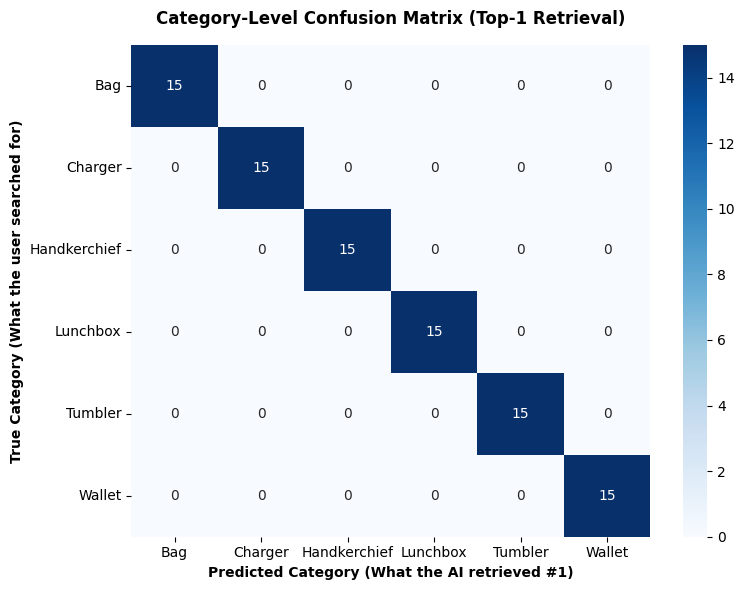


✅ Evaluation Complete! These are your exact Chapter 4 deliverables.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 🔢 CELL 8: Confusion Matrix (Text + Heatmap)
# ══════════════════════════════════════════════════════════════
unique_cats = sorted(list(set(true_categories)))
cm           = confusion_matrix(true_categories, predicted_categories, labels=unique_cats)

print("\n" + "="*50)
print("🔢  CATEGORY-LEVEL CONFUSION MATRIX (RAW NUMBERS)")
print("="*50)

cm_df = pd.DataFrame(cm, index=unique_cats, columns=unique_cats)
cm_df.index.name = 'True \\ Predicted'
print(cm_df)

print("="*50 + "\n")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=unique_cats, yticklabels=unique_cats
)
plt.title('Category-Level Confusion Matrix (Top-1 Retrieval)', fontweight='bold', pad=15)
plt.ylabel('True Category (What the user searched for)', fontweight='bold')
plt.xlabel('Predicted Category (What the AI retrieved #1)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Evaluation Complete! These are your exact Chapter 4 deliverables.")

In [ ]:
# ══════════════════════════════════════════════════════════════
# 🚨 CELL 9: Comprehensive Failure Analysis (R@1, R@5, R@10)
# ══════════════════════════════════════════════════════════════
import numpy as np

failed_r1 = []
failed_r5 = []
failed_r10 = []

print("\n" + "="*60)
print("🚨  COMPREHENSIVE FAILURE ANALYSIS 🚨")
print("="*60)

for i in range(num_test_items):
    target_name = test_item_names[i]
    correct_match_idx = gallery_item_names.index(target_name)

    query_scores   = similarity_matrix[i]
    ranked_indices = np.argsort(query_scores)[::-1]

    # Calculate exactly where the true item ended up (1-based indexing)
    actual_rank = np.where(ranked_indices == correct_match_idx)[0][0] + 1

    # If it didn't get Rank 1, it's an R@1 failure
    if actual_rank > 1:
        failed_r1.append(i)

        # Categorize the severity of the failure
        if actual_rank > 10:
            severity = "⚠️ FAILED RECALL@10"
            failed_r10.append(i)
        elif actual_rank > 5:
            severity = "⚠️ FAILED RECALL@5 (But passed R@10)"
            failed_r5.append(i)
        else:
            severity = "📍 Failed R@1 (But passed R@5)"

        print(f"\n❌ Failure at Index: {i}  [{severity}]")
        print(f"   True Rank:     #{actual_rank} out of {len(gallery_item_names)}")
        print(f"   Text Query:    '{queries[i]}'")
        print(f"   Correct Image: {target_name}")
        print(f"   AI's #1 Guess: {gallery_item_names[ranked_indices[0]]}")

print("\n" + "="*60)
print("📊  FAILURE SUMMARY")
print("="*60)
print(f"Total Queries that failed R@1:  {len(failed_r1)} items")
print(f"Total Queries that failed R@5:  {len(failed_r5)} items")
print(f"Total Queries that failed R@10: {len(failed_r10)} items -> Indices: {failed_r10}")
print("="*60)


🚨  COMPREHENSIVE FAILURE ANALYSIS 🚨

❌ Failure at Index: 4  [📍 Failed R@1 (But passed R@5)]
   True Rank:     #4 out of 600
   Text Query:    'Light-grey rectangular lunch box, pale blue latch clips and flap compartment, white oval shaped vent button on lid'
   Correct Image: lunchbox_050
   AI's #1 Guess: lunchbox_074

❌ Failure at Index: 8  [📍 Failed R@1 (But passed R@5)]
   True Rank:     #2 out of 600
   Text Query:    'Cream/beige matte plastic rectangular lunchbox, wave-embossed ridged lid surface, circular stainless steel vent/seal inset on top with daisy flower valve, brown side snap-latch clips'
   Correct Image: lunchbox_075
   AI's #1 Guess: lunchbox_100

❌ Failure at Index: 9  [📍 Failed R@1 (But passed R@5)]
   True Rank:     #2 out of 600
   Text Query:    'Steel blue matte plastic rectangular "Bento box" lunchbox, clear plastic windowed lid compartment housing a white spoon and fork set, recessed front latch tab, rounded corners'
   Correct Image: lunchbox_079
   AI's #1

Fixed query matched test index 4: Light-grey rectangular lunch box, pale blue latch clips and flap compartment, white oval shaped vent button on lid

🔍  SEARCHING:  "Light-grey rectangular lunch box, pale blue latch clips and flap compartment, white oval shaped vent button on lid"
    True Match:  lunchbox_050


/tmp/ipykernel_4633/2104244356.py:73: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4633/2104244356.py:73: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


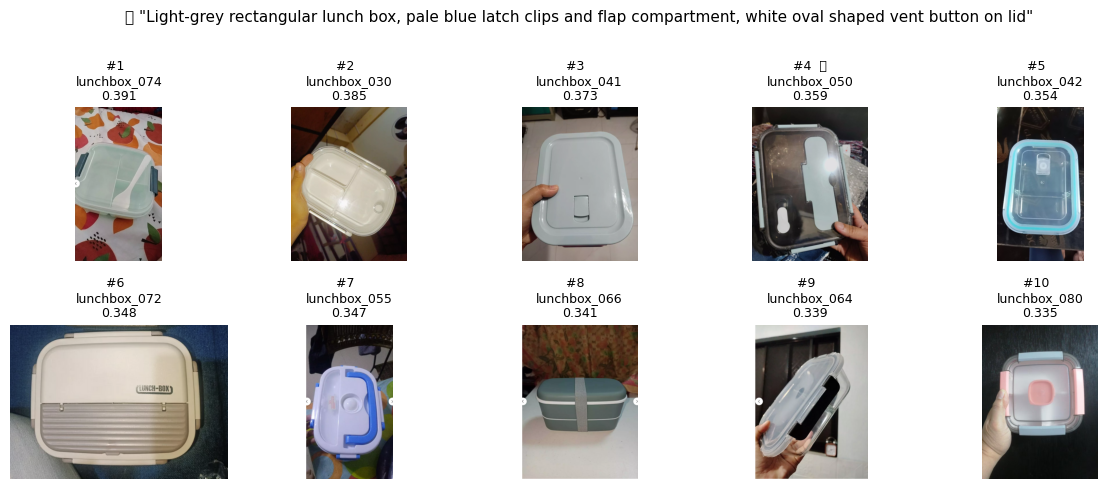


------------------------------------------------------------
Rank   Item Name                      Score      Status
------------------------------------------------------------
#1     lunchbox_074                   0.3915   📍 Top-1
#2     lunchbox_030                   0.3855   📍 Top-2
#3     lunchbox_041                   0.3727   📍 Top-3
#4     lunchbox_050                   0.3589   ✅ CORRECT
#5     lunchbox_042                   0.3539   📍 Top-5
#6     lunchbox_072                   0.3481   📍 Top-6
#7     lunchbox_055                   0.3474   📍 Top-7
#8     lunchbox_066                   0.3408   📍 Top-8
#9     lunchbox_064                   0.3393   📍 Top-9
#10    lunchbox_080                   0.3354   📍 Top-10
------------------------------------------------------------


In [ ]:
# ══════════════════════════════════════════════════════════════
# 🎯 CELL 10: Fixed Query Retrieval Demo (FIXED FOR LARGE GALLERY)
# Uses the predefined query instead of random selection
# ══════════════════════════════════════════════════════════════

import random
import matplotlib.pyplot as plt
import numpy as np

def show_top_k_results(query_idx, k=10, all_queries=None, gallery_names=None, target_names=None, similarity_matrix_or_scores=None):
    """
    Simulates a text-based image search:
    - Shows the query caption
    - Displays Top-K results in a single grid from the massive gallery
    - Labels each result with its recall rank
    """
    if all_queries is None:
        all_queries = queries
    if gallery_names is None:
        gallery_names = gallery_item_names
    if target_names is None:
        target_names = test_item_names

    # Determine if we have a full matrix or just a 1D score vector
    is_matrix = (similarity_matrix_or_scores is not None and
                 hasattr(similarity_matrix_or_scores, 'shape') and
                 len(similarity_matrix_or_scores.shape) == 2)

    if is_matrix:
        query_scores   = similarity_matrix_or_scores[query_idx]
        ranked_indices = np.argsort(query_scores)[::-1]

        # 🚨 THE FIX: Find where the true image is actually located in the massive 360-item gallery
        target_name = target_names[query_idx]
        correct_image_idx = gallery_names.index(target_name)
    else:
        query_scores   = similarity_matrix_or_scores
        ranked_indices = np.argsort(query_scores)[::-1]
        correct_image_idx = None  # No ground truth when using free-form query

    query_caption = all_queries[query_idx]

    print("\n" + "="*60)
    print(f"🔍  SEARCHING:  \"{query_caption}\"")
    if correct_image_idx is not None:
        print(f"    True Match:  {gallery_names[correct_image_idx]}")
    print("="*60)

    top_k_indices = ranked_indices[:k]
    cols = 5
    rows = (k + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 2.4))
    axes = axes.flatten() if k > 1 else [axes]

    for rank, idx in enumerate(top_k_indices, start=1):
        ax = axes[rank - 1]
        img = gallery_images[idx]
        score = query_scores[idx]
        is_correct = (idx == correct_image_idx) if correct_image_idx is not None else False

        recall_label = f"#{rank}"
        status_label = "✅" if is_correct else ""

        ax.imshow(img)
        ax.set_title(f"{recall_label}  {status_label}\n{gallery_names[idx]}\n{score:.3f}", fontsize=9)
        ax.axis('off')

    for i in range(k, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f"🔍 \"{query_caption}\"", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    print("\n" + "-"*60)
    print(f"{'Rank':<6} {'Item Name':<30} {'Score':<10} {'Status'}")
    print("-"*60)
    for rank, idx in enumerate(top_k_indices, start=1):
        is_correct = (idx == correct_image_idx) if correct_image_idx is not None else False
        status = "✅ CORRECT" if is_correct else f"📍 Top-{rank}"
        print(f"#{rank:<5} {gallery_names[idx]:<30} {query_scores[idx]:.4f}   {status}")
    print("-"*60)


# ─── Fixed query ────────────────────────────────────────────────
FIXED_QUERY = "Light-grey rectangular lunch box, pale blue latch clips and flap compartment, white oval shaped vent button on lid"

matched_idx = None
for idx, cap in enumerate(queries):
    if FIXED_QUERY.lower() in cap.lower() or cap.lower() in FIXED_QUERY.lower():
        matched_idx = idx
        break

if matched_idx is not None:
    print(f"Fixed query matched test index {matched_idx}: {queries[matched_idx]}")
    show_top_k_results(
        query_idx=matched_idx,
        k=10,
        all_queries=queries,
        gallery_names=gallery_item_names,
        target_names=test_item_names,
        similarity_matrix_or_scores=similarity_matrix
    )
else:
    print(f"⚠️ Could not find '{FIXED_QUERY}' in the test queries.")

In [ ]:
# 🎯 CELL: Exhaustive Evaluation Results & Failure Summary
def print_evaluation_summary():
    import torch, platform, os
    import numpy as np
    
    out = []
    out.append("=" * 80)
    out.append("🔬 FINAL BOSS: EXHAUSTIVE EVALUATION RESULTS SUMMARY")
    out.append("=" * 80)
    
    # 1. Environment & Hardware
    out.append("\n[1] HARDWARE & ENVIRONMENT")
    try: 
        out.append(f"    🖥️  OS:              {platform.system()} {platform.release()}")
        if torch.cuda.is_available():
            out.append(f"    🚀 GPU Used:        {torch.cuda.get_device_name(0)}")
        else:
            out.append("    🐌 GPU Used:        None (Evaluated on CPU)")
    except Exception as e: out.append(f"    ⚠️  Error: {e}")

    # 2. Models Evaluated
    out.append("\n[2] MODELS EVALUATED")
    try: out.append(f"    🤖 Base Model:      {model_id}")
    except NameError: pass
    try: out.append(f"    🔌 LoRA Adapter:    {os.path.basename(lora_path) if 'lora_path' in globals() else 'None (Zero-Shot)'}")
    except Exception: pass

    # 3. Dataset Complexity
    out.append("\n[3] DATASET COMPLEXITY")
    try: out.append(f"    🔍 Total Queries:   {len(queries)}")
    except NameError: pass
    try: out.append(f"    🖼️  Gallery Size:    {len(gallery_images)}")
    except NameError: pass
    try: out.append(f"    📏 Max Text Length: {processor.tokenizer.model_max_length} tokens")
    except NameError: pass

    # 4. Final Metrics
    out.append("\n[4] 🏆 FINAL RETRIEVAL METRICS 🏆")
    try:
        out.append(f"    🥇 Recall@1:        {r1_score:.2f}%")
        out.append(f"    🥈 Recall@5:        {r5_score:.2f}%")
        out.append(f"    🥉 Recall@10:       {r10_score:.2f}%")
        out.append(f"    📈 MRR:             {mrr_score:.4f}")
    except NameError:
        out.append("    ⚠️  Could not find metric variables.")

    # 5. Failure Analysis Summary
    out.append("\n[5] 📉 FAILURE ANALYSIS SUMMARY")
    try:
        catastrophic = num_test_items - recall_10
        near_misses = recall_10 - recall_1
        perfect = recall_1
        
        out.append(f"    🎯 Perfect First-Tries: {perfect:>2} queries ({(perfect/num_test_items)*100:.1f}%) - Nailed it at Rank 1")
        out.append(f"    🤏 Near Misses:         {near_misses:>2} queries ({(near_misses/num_test_items)*100:.1f}%) - Found in top 10, but missed Rank 1")
        out.append(f"    💥 Severe Failures:     {catastrophic:>2} queries ({(catastrophic/num_test_items)*100:.1f}%) - Failed to find in top 10")
        out.append(f"    -------------------------------------------------------------------------")
        out.append(f"    Total Test Queries:     {num_test_items:>2} queries")
        
        if 'true_categories' in globals() and 'predicted_categories' in globals():
            correct_cats = sum(1 for t, p in zip(true_categories, predicted_categories) if t == p)
            category_accuracy = (correct_cats / num_test_items) * 100
            out.append(f"\n    📦 Category Accuracy:   {category_accuracy:.2f}% ({correct_cats} queries guessed the correct object type)")
    except NameError:
        out.append("    ⚠️  Could not find failure analysis variables.")

        # 6. Sample Retrieval Leaderboard (Demo)
    out.append("\n[6] 📋 SAMPLE RETRIEVAL LEADERBOARD")
    try:
        # DYNAMIC FIX: Automatically use whatever query you searched for in Cell 10!
        if 'matched_idx' in globals() and matched_idx is not None:
            demo_idx = matched_idx
        else:
            demo_idx = 0 # Fallback just in case

        target_name = test_item_names[demo_idx]
        correct_match_idx = gallery_item_names.index(target_name)
        
        query_scores = similarity_matrix[demo_idx]
        ranked_indices = np.argsort(query_scores)[::-1]
        
        out.append(f"    🔍 Query: \"{queries[demo_idx]}\"\n")
        out.append(f"    Rank   Item Name                      Score      Status")
        out.append(f"    ------------------------------------------------------------")
        
        for rank in range(10):
            gal_idx = ranked_indices[rank]
            item_name = gallery_item_names[gal_idx]
            score = query_scores[gal_idx]
            
            if gal_idx == correct_match_idx:
                status = "✅ TRUE MATCH"
            else:
                status = f"📍 Top-{rank+1}"
                
            out.append(f"    #{rank+1:<5} {item_name:<30} {score:.4f}   {status}")
            
    except NameError:
         out.append("    ⚠️  Could not find similarity matrix to generate leaderboard.")

    out.append("=" * 80)
        # === NEW: PRINT AND SAVE TO FILE ===
    report_text = "\n".join(out)
    print(report_text)

    try:
        import os
        # If testing a specific LoRA, save the report inside its folder
        if 'adapter_path' in globals() and os.path.exists(adapter_path):
            txt_path = os.path.join(adapter_path, "evaluation_summary_report.txt")
        else:
            # Fallback if testing the Base Zero-Shot model
            txt_path = "zero_shot_evaluation_report.txt" 
            
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(report_text)
        print(f"\n💾 Evaluation Summary safely saved to: {txt_path}")
    except Exception as e:
        print(f"\n⚠️ Could not save text file: {e}")

# Run the summary
print_evaluation_summary()


In [ ]:
# ══════════════════════════════════════════════════════════════
# 🔍 CELL 11: STANDALONE INTERACTIVE LIVE SEARCH ENGINE DEMO
# ══════════════════════════════════════════════════════════════
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. This will pop up a text box in your notebook asking for input!
LIVE_QUERY = input("🔍 Enter your custom search query: ")

if not LIVE_QUERY.strip():
    print("⚠️ You didn't type anything! Please run the cell again.")
else:
    print(f"\nGenerating embeddings for: '{LIVE_QUERY}'...")

    with torch.no_grad():
        # Pass your custom text into the processor
        live_inputs = processor(
            text=[LIVE_QUERY],
            images=[gallery_images[0]], # Dummy image required by processor
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        # Get the text embedding
        live_outputs = lora_model(**live_inputs)
        live_embeds = live_outputs.text_embeds
        live_embeds = live_embeds / live_embeds.norm(p=2, dim=-1, keepdim=True)

        # Multiply against the massive gallery image embeddings calculated in Cell 7
        live_scores = (live_embeds @ image_embeds.T).cpu().numpy()[0]

    # 2. Sort the scores to find the Top 10
    k = 10
    ranked_indices = np.argsort(live_scores)[::-1]
    top_k_indices = ranked_indices[:k]
    
    # 3. Create the Visual Image Grid
    cols = 5
    rows = (k + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 2.4))
    axes = axes.flatten()

    for rank, idx in enumerate(top_k_indices, start=1):
        ax = axes[rank - 1]
        img = gallery_images[idx]
        score = live_scores[idx]

        ax.imshow(img)
        ax.set_title(f"#{rank}\n{gallery_item_names[idx]}\n{score:.3f}", fontsize=9)
        ax.axis('off')

    for i in range(k, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f"🔍 \"{LIVE_QUERY}\"", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # 4. Print the clean Leaderboard (No Status Column!)
    print("\n" + "-"*60)
    print(f"{'Rank':<6} {'Item Name':<30} {'Score':<10}")
    print("-"*60)
    for rank, idx in enumerate(top_k_indices, start=1):
        print(f"#{rank:<5} {gallery_item_names[idx]:<30} {live_scores[idx]:.4f}")
    print("-"*60)
